<a href="https://colab.research.google.com/github/Estabraq-makiyah/Estabraq/blob/main/Python%E2%80%91based_IoT%E2%80%93edge%E2%80%93cloud_MEC_simulator_Senario_1_moderate_load.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Cell 1: imports and environment

import numpy as np
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Make plots appear in Colab
%matplotlib inline

class EdgeEnv:
    def __init__(self, num_nodes, neighbours, cpu_caps, link_rates, tx_powers,
                 task_arrival_rate, D_range, C_range, delta_range,
                 alpha, beta, lam):
        self.num_nodes = num_nodes
        self.neighbours = neighbours        # list of lists of neighbour indices
        self.cpu_caps = cpu_caps            # array size N
        self.link_rates = link_rates        # N x N matrix
        self.tx_powers = tx_powers          # N x N matrix
        self.task_arrival_rate = task_arrival_rate
        self.D_range = D_range
        self.C_range = C_range
        self.delta_range = delta_range
        self.alpha = alpha
        self.beta = beta
        self.lam = lam

        self.reset()

    def reset(self):
        self.time = 0
        self.cpu_load = np.zeros(self.num_nodes, dtype=float)
        self.queue_len = np.zeros(self.num_nodes, dtype=int)
        self.tasks = [[] for _ in range(self.num_nodes)]   # simple per‑node queues

        # metrics
        self.total_delay = 0.0
        self.total_energy = 0.0
        self.total_tasks = 0
        self.missed_deadlines = 0

        self._generate_arrivals()
        return self._get_states()

    def _generate_arrivals(self):
        # Poisson(λ) arrivals per node per step (simplified)
        for i in range(self.num_nodes):
            num = np.random.poisson(self.task_arrival_rate)
            for _ in range(num):
                D = np.random.uniform(*self.D_range)
                C = np.random.uniform(*self.C_range)
                delta = np.random.uniform(*self.delta_range)
                task = {"D": D, "C": C, "delta": delta}
                self.tasks[i].append(task)
                self.queue_len[i] += 1

    def _get_states(self):
        states = []
        max_q = max(1, int(np.max(self.queue_len)))
        for i in range(self.num_nodes):
            cpu_norm = self.cpu_load[i] / (self.cpu_caps[i] + 1e-8)
            q_norm = self.queue_len[i] / max_q
            # neighbour summary: mean CPU + mean queue
            neigh = self.neighbours[i]
            if neigh:
                neigh_cpu = np.mean(self.cpu_load[neigh] / (self.cpu_caps[neigh] + 1e-8))
                neigh_q = np.mean(self.queue_len[neigh] / max_q)
            else:
                neigh_cpu, neigh_q = 0.0, 0.0
            s = np.array([cpu_norm, q_norm, neigh_cpu, neigh_q], dtype=np.float32)
            states.append(s)
        return states  # list of np.array, one per node

    def _local_exec(self, node, task):
        D, C = task["D"], task["C"]
        f = self.cpu_caps[node]
        T_local = (D * C) / (f + 1e-8)
        K = 1e-27  # example hardware constant
        E_local = K * (f ** 2) * T_local
        return T_local, E_local

    def _tx_and_remote(self, src, dst, task, extra_latency=0.0):
        D, C = task["D"], task["C"]
        R = self.link_rates[src, dst]
        p_tx = self.tx_powers[src, dst]
        T_tx = D / (R + 1e-8)
        E_tx = p_tx * T_tx
        f_remote = self.cpu_caps[dst]
        T_remote = (D * C) / (f_remote + 1e-8)
        K = 1e-27
        E_remote = K * (f_remote ** 2) * T_remote
        return T_tx + T_remote + extra_latency, E_tx + E_remote

    def step(self, actions):
        """
        actions: list of integers, len = num_nodes
        action 0   = local execution (if queue non‑empty)
        action 1..k = offload to neighbours[i][a-1]
        action k+1 = offload to cloud (simple high‑latency model)
        """
        rewards = np.zeros(self.num_nodes, dtype=float)
        done = False

        for i in range(self.num_nodes):
            if not self.tasks[i]:
                continue
            task = self.tasks[i].pop(0)
            self.queue_len[i] -= 1

            a = actions[i]
            # 0: local
            if a == 0:
                T_tot, E_tot = self._local_exec(i, task)
            # 1..len(neighbours[i]): offload to neighbour
            elif 1 <= a <= len(self.neighbours[i]):
                dst = self.neighbours[i][a - 1]
                T_tot, E_tot = self._tx_and_remote(i, dst, task)
            else:
                # cloud: model as higher extra latency
                dst = i  # reuse local CPU as placeholder
                T_tot, E_tot = self._tx_and_remote(i, dst, task, extra_latency=0.1)

            # update loads (very simple utilisation model)
            self.cpu_load[i] = max(0.0, self.cpu_load[i] - 0.1)

            # update metrics
            delta = task["delta"]
            self.total_delay += T_tot
            self.total_energy += E_tot
            self.total_tasks += 1
            if T_tot > delta:
                self.missed_deadlines += 1

            # reward
            r = -(self.alpha * T_tot + self.beta * E_tot)
            if T_tot > delta:
                r -= self.lam
            rewards[i] = r

        # new arrivals for next step
        self._generate_arrivals()
        self.time += 1
        next_states = self._get_states()
        return next_states, rewards, done, {}


In [12]:
# Cell 2: DQN, replay buffer, training with logging and plotting support

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2):
        self.buf.append((s, a, r, s2))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2 = zip(*batch)
        return (torch.tensor(s, dtype=torch.float32),
                torch.tensor(a, dtype=torch.long),
                torch.tensor(r, dtype=torch.float32),
                torch.tensor(s2, dtype=torch.float32))

    def __len__(self):
        return len(self.buf)

def train(env, num_actions, num_episodes=100, max_steps=200,
          gamma=0.99, lr=1e-3, batch_size=64, epsilon_start=1.0,
          epsilon_end=0.05, epsilon_decay=0.99, target_update=200):

    # state dimension from environment
    state_dim = len(env._get_states()[0])

    policy_net = DQN(state_dim, num_actions)
    target_net = DQN(state_dim, num_actions)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimiser = optim.Adam(policy_net.parameters(), lr=lr)
    buffer = ReplayBuffer(100000)

    epsilon = epsilon_start
    step_count = 0

    episode_rewards = []
    episode_miss_ratios = []

    for ep in range(num_episodes):
        states = env.reset()
        episode_reward = 0.0

        for t in range(max_steps):
            actions = []
            for s in states:
                if random.random() < epsilon:
                    a = random.randrange(num_actions)
                else:
                    with torch.no_grad():
                        q_vals = policy_net(torch.tensor(s, dtype=torch.float32))
                        a = int(torch.argmax(q_vals).item())
                actions.append(a)

            next_states, rewards, done, _ = env.step(actions)

            # store transitions for all nodes
            for i in range(env.num_nodes):
                buffer.push(states[i], actions[i], rewards[i], next_states[i])
                episode_reward += rewards[i]

            states = next_states
            step_count += 1

            # update network
            if len(buffer) >= batch_size:
                s_batch, a_batch, r_batch, s2_batch = buffer.sample(batch_size)
                q_values = policy_net(s_batch).gather(1, a_batch.view(-1, 1)).squeeze(1)
                with torch.no_grad():
                    q_next = target_net(s2_batch).max(1)[0]
                    y = r_batch + gamma * q_next
                loss = nn.functional.mse_loss(q_values, y)
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            # update target net periodically
            if step_count % target_update == 0:
                target_net.load_state_dict(policy_net.state_dict())

        # decay epsilon
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        # episode metrics
        if env.total_tasks > 0:
            miss_ratio = env.missed_deadlines / env.total_tasks
        else:
            miss_ratio = 0.0

        episode_rewards.append(episode_reward)
        episode_miss_ratios.append(miss_ratio)

        print(f"Episode {ep+1:3d} | reward={episode_reward:8.2f} "
              f"| miss_ratio={miss_ratio:.3f} | epsilon={epsilon:.3f}")

    return policy_net, episode_rewards, episode_miss_ratios


Episode   1 | reward=-2357.38 | miss_ratio=0.510 | epsilon=0.980
Episode   2 | reward=-2310.85 | miss_ratio=0.489 | epsilon=0.960
Episode   3 | reward=-2512.01 | miss_ratio=0.517 | epsilon=0.941
Episode   4 | reward=-2175.92 | miss_ratio=0.473 | epsilon=0.922
Episode   5 | reward=-1954.92 | miss_ratio=0.416 | epsilon=0.904
Episode   6 | reward=-2298.16 | miss_ratio=0.489 | epsilon=0.886
Episode   7 | reward=-2115.61 | miss_ratio=0.437 | epsilon=0.868
Episode   8 | reward=-1996.00 | miss_ratio=0.415 | epsilon=0.851
Episode   9 | reward=-2410.33 | miss_ratio=0.480 | epsilon=0.834
Episode  10 | reward=-1806.29 | miss_ratio=0.420 | epsilon=0.817
Episode  11 | reward=-2062.76 | miss_ratio=0.446 | epsilon=0.801
Episode  12 | reward=-2044.20 | miss_ratio=0.421 | epsilon=0.785
Episode  13 | reward=-2022.91 | miss_ratio=0.412 | epsilon=0.769
Episode  14 | reward=-1698.56 | miss_ratio=0.354 | epsilon=0.754
Episode  15 | reward=-1798.19 | miss_ratio=0.382 | epsilon=0.739
Episode  16 | reward=-207

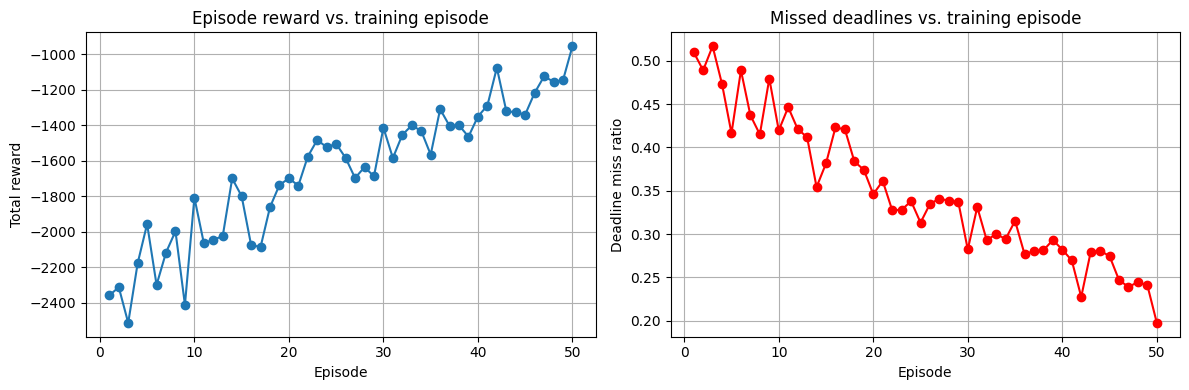

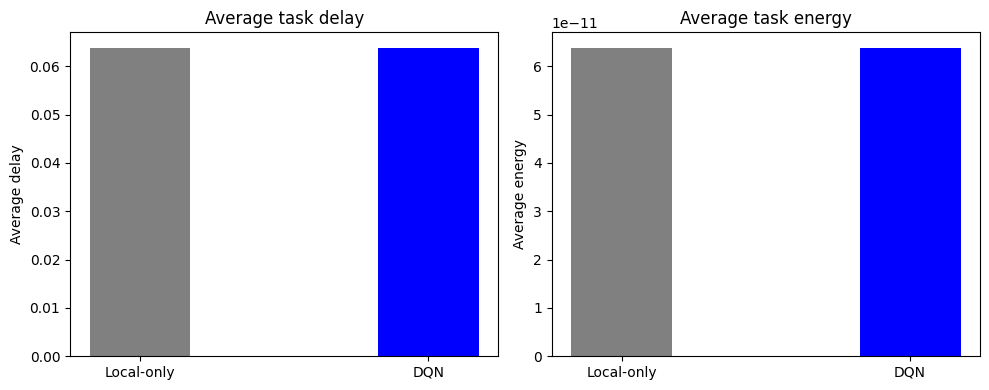

In [13]:
# Cell 3: instantiate environment, train DQN, evaluate baselines, plot results

# ---- Define simple network and parameters ----
num_nodes = 5
# Line topology: 0-1-2-3-4
neighbours = [[1], [0,2], [1,3], [2,4], [3]]

cpu_caps = np.array([1e9]*num_nodes)               # CPU capacities (cycles/s)
link_rates = np.ones((num_nodes, num_nodes))*1e6   # 1 Mbps between all nodes (simplified)
tx_powers  = np.ones((num_nodes, num_nodes))*0.5   # 0.5 W (simplified)

task_arrival_rate = 1.0                            # average tasks per node per step
D_range     = (5e4, 1e5)                           # bits
C_range     = (500, 1200)                           # CPU cycles per bit
delta_range = (0.05, 0.2)                           # seconds
alpha, beta, lam = 1.0, 1.0, 10.0                  # cost weights

env = EdgeEnv(num_nodes, neighbours, cpu_caps, link_rates, tx_powers,
              task_arrival_rate, D_range, C_range, delta_range,
              alpha, beta, lam)

# Actions: 0 = local, 1 = first neighbour, 2 = cloud
num_actions = 3

# ---- Train DQN ----
policy_net, episode_rewards, episode_miss_ratios = train(
    env,
    num_actions=num_actions,
    num_episodes=50,      # increase for smoother curves if needed
    max_steps=100,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.98,
    target_update=200
)

# ---- Baseline: local-only policy (always action 0) ----
def evaluate_local_only(env, num_episodes=20, max_steps=100):
    avg_delays = []
    avg_energies = []
    miss_ratios = []

    for ep in range(num_episodes):
        env.reset()
        for t in range(max_steps):
            actions = [0] * env.num_nodes  # always local
            _, _, _, _ = env.step(actions)

        if env.total_tasks > 0:
            avg_delay  = env.total_delay / env.total_tasks
            avg_energy = env.total_energy / env.total_tasks
            miss_ratio = env.missed_deadlines / env.total_tasks
        else:
            avg_delay = avg_energy = miss_ratio = 0.0

        avg_delays.append(avg_delay)
        avg_energies.append(avg_energy)
        miss_ratios.append(miss_ratio)

        print(f"[Local-only] Episode {ep+1:3d} | "
              f"avg_delay={avg_delay:.4f} | "
              f"avg_energy={avg_energy:.4e} | "
              f"miss_ratio={miss_ratio:.3f}")

    return avg_delays, avg_energies, miss_ratios

local_delays, local_energies, local_miss = evaluate_local_only(env)

# ---- Evaluate learned DQN policy (greedy, ε = 0) ----
def evaluate_policy(env, policy_net, num_actions, num_episodes=20, max_steps=100):
    avg_delays = []
    avg_energies = []
    miss_ratios = []

    for ep in range(num_episodes):
        env.reset()
        for t in range(max_steps):
            states = env._get_states()
            actions = []
            for s in states:
                with torch.no_grad():
                    q_vals = policy_net(torch.tensor(s, dtype=torch.float32))
                    a = int(torch.argmax(q_vals).item())
                actions.append(a)
            _, _, _, _ = env.step(actions)

        if env.total_tasks > 0:
            avg_delay  = env.total_delay / env.total_tasks
            avg_energy = env.total_energy / env.total_tasks
            miss_ratio = env.missed_deadlines / env.total_tasks
        else:
            avg_delay = avg_energy = miss_ratio = 0.0

        avg_delays.append(avg_delay)
        avg_energies.append(avg_energy)
        miss_ratios.append(miss_ratio)

        print(f"[DQN]       Episode {ep+1:3d} | "
              f"avg_delay={avg_delay:.4f} | "
              f"avg_energy={avg_energy:.4e} | "
              f"miss_ratio={miss_ratio:.3f}")

    return avg_delays, avg_energies, miss_ratios

dqn_delays, dqn_energies, dqn_miss = evaluate_policy(env, policy_net, num_actions)

# ---- Print mean comparison ----
print("\n=== Mean performance over evaluation episodes ===")
print("Local-only: mean delay  {:.4f}, mean energy {:.4e}, miss_ratio {:.3f}"
      .format(np.mean(local_delays), np.mean(local_energies), np.mean(local_miss)))
print("DQN:        mean delay  {:.4f}, mean energy {:.4e}, miss_ratio {:.3f}"
      .format(np.mean(dqn_delays),   np.mean(dqn_energies),   np.mean(dqn_miss)))

# ---- Plot learning curves ----
episodes = np.arange(1, len(episode_rewards)+1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(episodes, episode_rewards, marker='o')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('Episode reward vs. training episode')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(episodes, episode_miss_ratios, marker='o', color='red')
plt.xlabel('Episode')
plt.ylabel('Deadline miss ratio')
plt.title('Missed deadlines vs. training episode')
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Plot baseline vs DQN (mean delay and energy) ----
labels = ['Local-only', 'DQN']
mean_delays  = [np.mean(local_delays),  np.mean(dqn_delays)]
mean_energies = [np.mean(local_energies), np.mean(dqn_energies)]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(x, mean_delays, width, color=['grey', 'blue'])
plt.xticks(x, labels)
plt.ylabel('Average delay')
plt.title('Average task delay')

plt.subplot(1,2,2)
plt.bar(x, mean_energies, width, color=['grey', 'blue'])
plt.xticks(x, labels)
plt.ylabel('Average energy')
plt.title('Average task energy')

plt.tight_layout()
plt.show()


In [10]:
# Baseline: local-only policy (always action 0)

def evaluate_local_only(env, num_episodes=20, max_steps=100):
    avg_delays = []
    avg_energies = []
    miss_ratios = []

    for ep in range(num_episodes):
        env.reset()
        for t in range(max_steps):
            actions = [0] * env.num_nodes  # always local
            _, _, _, _ = env.step(actions)

        if env.total_tasks > 0:
            avg_delay = env.total_delay / env.total_tasks
            avg_energy = env.total_energy / env.total_tasks
            miss_ratio = env.missed_deadlines / env.total_tasks
        else:
            avg_delay = avg_energy = miss_ratio = 0.0

        avg_delays.append(avg_delay)
        avg_energies.append(avg_energy)
        miss_ratios.append(miss_ratio)

        print(f"[Local-only] Episode {ep+1:3d} | "
              f"avg_delay={avg_delay:.4f} | "
              f"avg_energy={avg_energy:.4e} | "
              f"miss_ratio={miss_ratio:.3f}")

    return avg_delays, avg_energies, miss_ratios

# run baseline
local_delays, local_energies, local_miss = evaluate_local_only(env)


[Local-only] Episode   1 | avg_delay=0.0070 | avg_energy=2.8132e-11 | miss_ratio=0.000
[Local-only] Episode   2 | avg_delay=0.0079 | avg_energy=3.1599e-11 | miss_ratio=0.000
[Local-only] Episode   3 | avg_delay=0.0072 | avg_energy=2.8840e-11 | miss_ratio=0.000
[Local-only] Episode   4 | avg_delay=0.0074 | avg_energy=2.9714e-11 | miss_ratio=0.000
[Local-only] Episode   5 | avg_delay=0.0072 | avg_energy=2.8829e-11 | miss_ratio=0.000
[Local-only] Episode   6 | avg_delay=0.0076 | avg_energy=3.0271e-11 | miss_ratio=0.000
[Local-only] Episode   7 | avg_delay=0.0079 | avg_energy=3.1489e-11 | miss_ratio=0.000
[Local-only] Episode   8 | avg_delay=0.0076 | avg_energy=3.0540e-11 | miss_ratio=0.000
[Local-only] Episode   9 | avg_delay=0.0075 | avg_energy=2.9984e-11 | miss_ratio=0.000
[Local-only] Episode  10 | avg_delay=0.0074 | avg_energy=2.9437e-11 | miss_ratio=0.000
[Local-only] Episode  11 | avg_delay=0.0073 | avg_energy=2.9194e-11 | miss_ratio=0.000
[Local-only] Episode  12 | avg_delay=0.0076